# Project 2: Predict to Invest - MLR Pipeline for Startup Profitability

**Course:** AI (ML | DL) Foundation Course  
**Institution:** Corvit / NAVTTC / SAI   
**Reference:**  
**Dataset:** 50 Startups (R&D Spend, Administration, Marketing Spend, State -> Profit)

---

### Problem Statement
You are a data scientist at a venture capital firm. Your team needs to predict which startups will be most profitable based on their spending across R&D, Administration, and Marketing departments. Build a **Multiple Linear Regression** model using the **50 Startups** dataset, evaluate its accuracy, and present feature importance insights to guide investment decisions.

Follow the complete industry-standard ML pipeline: Load -> EDA -> Preprocess -> Train -> Evaluate -> Interpret. Your final deliverable is this Jupyter notebook with visualizations, metrics, and a written business recommendation.

### What You Will Learn
- Difference between Simple vs Multiple Linear Regression
- Handling categorical features (One-Hot Encoding)
- Train/Test split and model training with scikit-learn
- Evaluation metrics: R2, MAE, MSE, RMSE
- Feature importance via regression coefficients
- Visualization of predictions vs actuals

---
**Student Name:** ________________  
**Date:** ________________

## Step 1: Import Libraries

Import all necessary libraries for data handling, visualization, preprocessing, model building, and evaluation.

**Hint:** You need `pandas`, `numpy`, `matplotlib`, `seaborn`, and from sklearn: `train_test_split`, `LinearRegression`, `r2_score`, `mean_absolute_error`, `mean_squared_error`.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Step 2: Load & Inspect the Dataset

Load the **50_Startups.csv** dataset. This dataset contains data on 50 startups with the following columns:

| Column | Type | Description |
|--------|------|-------------|
| R&D Spend | Float | Money spent on Research & Development |
| Administration | Float | Money spent on Administration |
| Marketing Spend | Float | Money spent on Marketing |
| State | Categorical | Location: New York, California, Florida |
| Profit | Float | **Target variable** — startup profit |

**Hint:** Use `pd.read_csv()`, then inspect with `.head()`, `.info()`, `.describe()`, and `.shape`.

In [6]:
df = pd.read_csv('50_startups_dataset.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,Pakistan,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Istanbul,191050.39
3,144372.41,118671.85,383199.62,Pakistan,182901.99
4,142107.34,91391.77,366168.42,Istanbul,166187.94


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB


In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [9]:
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset shape: (50, 5)
Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']


## Step 3: Exploratory Data Analysis (EDA)

Before building any model, **understand your data**. This is the most important step in any ML project.

### Tasks:
1. Check for missing values
2. Visualize the distribution of the target variable (Profit)
3. Plot correlation heatmap for numerical features
4. Visualize relationships between each feature and Profit
5. Analyze the categorical variable (State)

**Hint:** Use `sns.heatmap()` for correlation, `sns.pairplot()` for relationships, and `value_counts()` for State distribution.

In [10]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

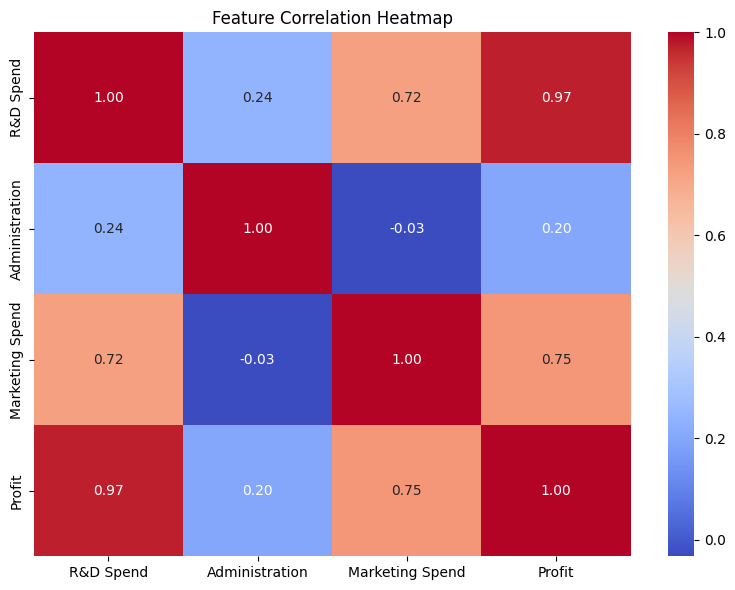

In [11]:
# Step 3b: Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

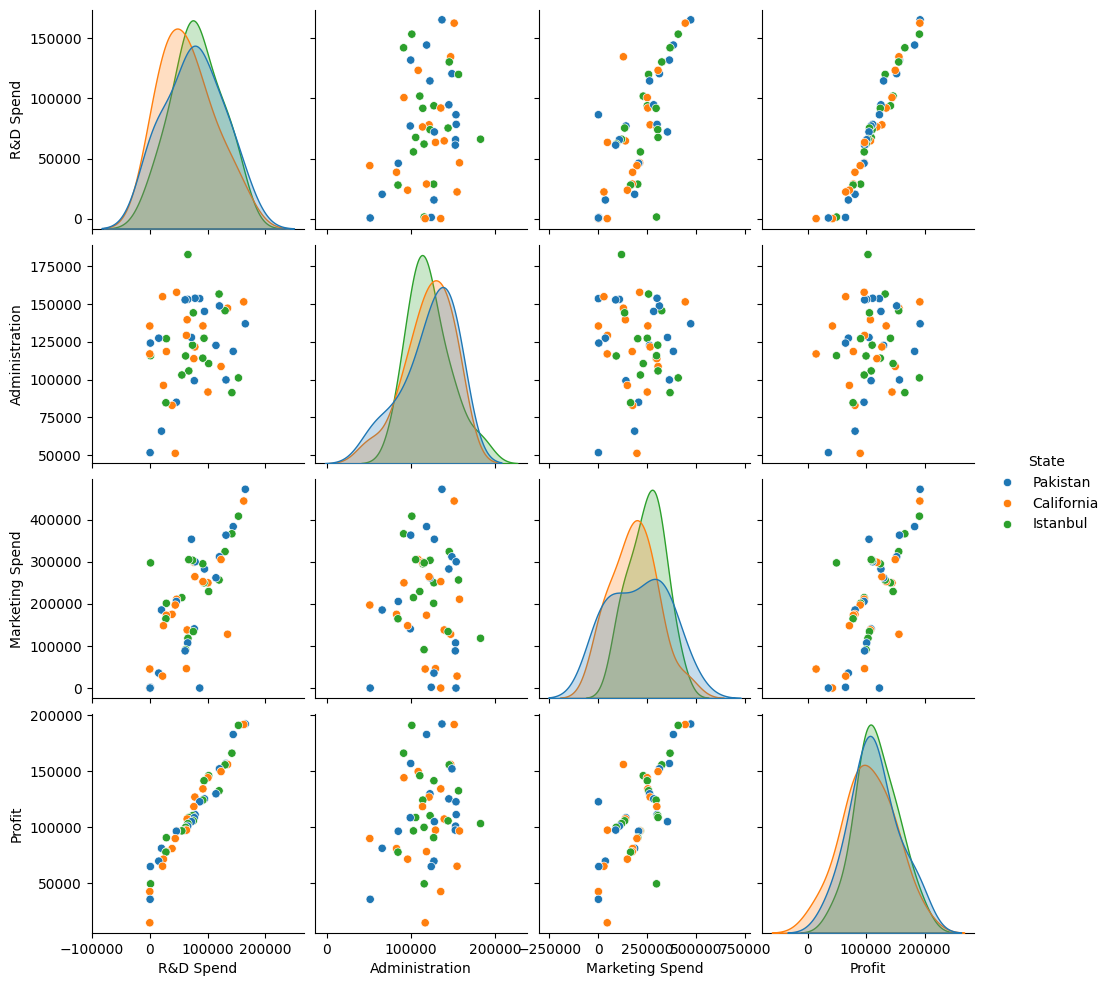

In [12]:
sns.pairplot(df, hue='State', diag_kind='kde')

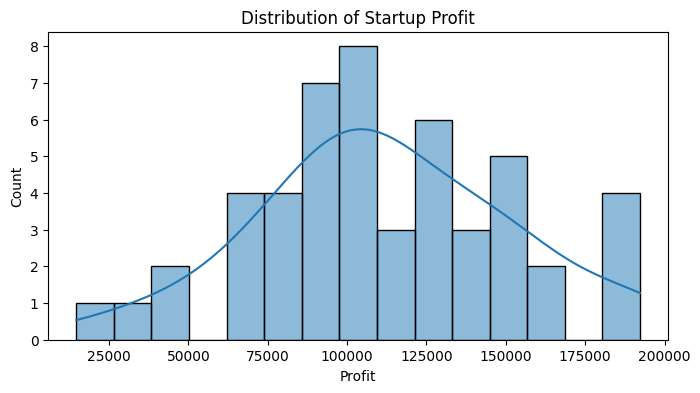

In [13]:

plt.figure(figsize=(8, 4))
sns.histplot(df['Profit'], kde=True, bins=15)
plt.title('Distribution of Startup Profit')
plt.show()

In [14]:
# Step 3e: State distribution
df['State'].value_counts()

State
Pakistan      17
California    17
Istanbul      16
Name: count, dtype: int64

## Step 4: Data Preprocessing

### Key Decisions:
1. **Separate features (X) and target (y)** - Profit is our target
2. **Handle the categorical variable (State)** - ML models need numbers, not text
3. **One-Hot Encoding** - Convert 'State' into binary columns

**Hint:** Use `pd.get_dummies()` for encoding. Set `drop_first=True` to avoid the **dummy variable trap** (multicollinearity).

**Key Concept - Dummy Variable Trap:**  
If you have 3 states (NY, CA, FL), you only need 2 binary columns. The third state is implied when both columns are 0. This avoids perfect multicollinearity.

In [15]:
df_encoded = pd.get_dummies(df, columns=['State'], drop_first=True)
df_encoded.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Istanbul,State_Pakistan
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [16]:

X = df_encoded.drop('Profit', axis=1)
y = df_encoded['Profit']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (50, 5)
Target shape: (50,)


## Step 5: Train/Test Split

Split the data into **training set (80%)** and **test set (20%)**. Use `random_state=42` for reproducibility.

**Hint:** Use `train_test_split(X, y, test_size=0.2, random_state=42)`

**Key Concept - Why Split?**  
- **Training set:** Model learns patterns from this data
- **Test set:** Model is evaluated on unseen data to check generalization
- **random_state:** Ensures the same split every time you run the code

In [17]:
# Step 5: Split the data


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 40 samples
Test set:     10 samples


## Step 6: Train the Multiple Linear Regression Model

Create a `LinearRegression` object and fit it on the training data.

**Hint:** 
```python
model = LinearRegression()
model.fit(X_train, y_train)
```

After training, the model learns:
- **Coefficients** (`model.coef_`) — weight/importance of each feature
- **Intercept** (`model.intercept_`) — the baseline profit when all features are 0

In [18]:

model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [19]:

print(f"Intercept: {model.intercept_:.2f}")
print("\nFeature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:25s} -> {coef:>12.2f}")

Intercept: 54028.04

Feature Coefficients:
  R&D Spend                 ->         0.81
  Administration            ->        -0.07
  Marketing Spend           ->         0.03
  State_Istanbul            ->       938.79
  State_Pakistan            ->         6.99


## Step 7: Make Predictions

Use the trained model to predict profits on the **test set** (unseen data).

**Hint:** Use `model.predict(X_test)` and compare `y_pred` vs `y_test`.

In [20]:
# Step 7: Predict on test data

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    'Actual Profit': y_test.values,
    'Predicted Profit': y_pred,
    'Difference': y_test.values - y_pred
})
comparison

,Actual Profit,Predicted Profit,Difference
0,134307.35,126362.879083,7944.470917
1,81005.76,84608.453836,-3602.693836
2,99937.59,99677.494251,260.095749
3,64926.08,46357.460686,18568.619314
4,125370.37,128750.482885,-3380.112885
5,35673.41,50912.417419,-15239.007419
6,105733.54,109741.350327,-4007.810327
7,107404.34,100643.242816,6761.097184
8,97427.84,97599.275746,-171.435746
9,122776.86,113097.425244,9679.434756


## Step 8: Model Evaluation

Evaluate using **industry-standard regression metrics**:

| Metric | Formula Intuition | Perfect Score |
|--------|-------------------|---------------|
| **R² Score** | How much variance is explained by the model | 1.0 |
| **MAE** | Average absolute error | 0.0 |
| **MSE** | Average squared error (penalizes large errors) | 0.0 |
| **RMSE** | Square root of MSE (same unit as target) | 0.0 |

**Hint:** Use `r2_score()`, `mean_absolute_error()`, `mean_squared_error()` from sklearn.metrics. RMSE = `np.sqrt(MSE)`.

In [21]:
# Step 8: Calculate evaluation metrics


r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("=" * 40)
print("  MODEL EVALUATION METRICS")
print("=" * 40)
print(f"  R2 Score : {r2:.4f}")
print(f"  MAE      : ${mae:,.2f}")
print(f"  MSE      : ${mse:,.2f}")
print(f"  RMSE     : ${rmse:,.2f}")
print("=" * 40)

  MODEL EVALUATION METRICS
  R2 Score : 0.8987
  MAE      : $6,961.48
  MSE      : $82,010,363.04
  RMSE     : $9,055.96


## Step 9: Visualize Results

Create two key plots:
1. **Actual vs Predicted** scatter plot — ideally falls on a 45° diagonal line
2. **Residual Distribution** — should be normally distributed around 0

**Hint:** For the diagonal line, plot `[min, max]` against itself. For residuals, calculate `y_test - y_pred`.

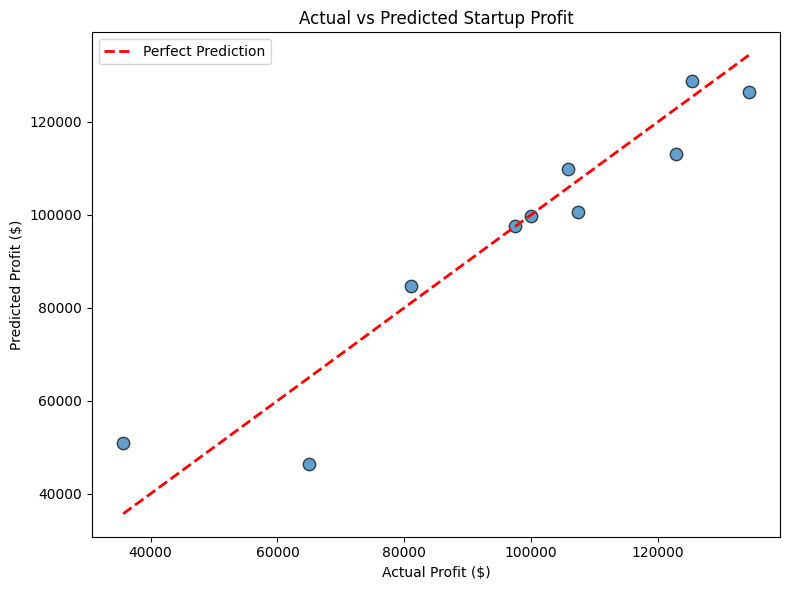

In [22]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolors='k', s=80)
line_range = [y_test.min(), y_test.max()]
plt.plot(line_range, line_range, 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Profit ($)')
plt.ylabel('Predicted Profit ($)')
plt.title('Actual vs Predicted Startup Profit')
plt.legend()
plt.tight_layout()
plt.show()

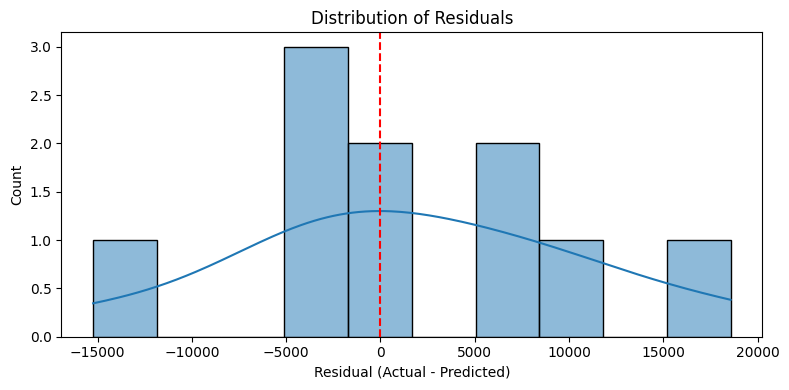

In [23]:
# Step 9b: Residual Distribution

residuals = y_test - y_pred
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True, bins=10)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Distribution of Residuals')
plt.xlabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

## Step 10: Feature Importance Analysis

Interpret which features have the **most impact** on startup profit.

**Hint:** Use `model.coef_` to get coefficients. A higher absolute value means greater influence. Plot as a horizontal bar chart.

**Key Insight for AI Engineers:**  
In real-world AI projects, **model interpretability** is as important as accuracy. Stakeholders want to know *why* the model makes its predictions, not just *what* it predicts.

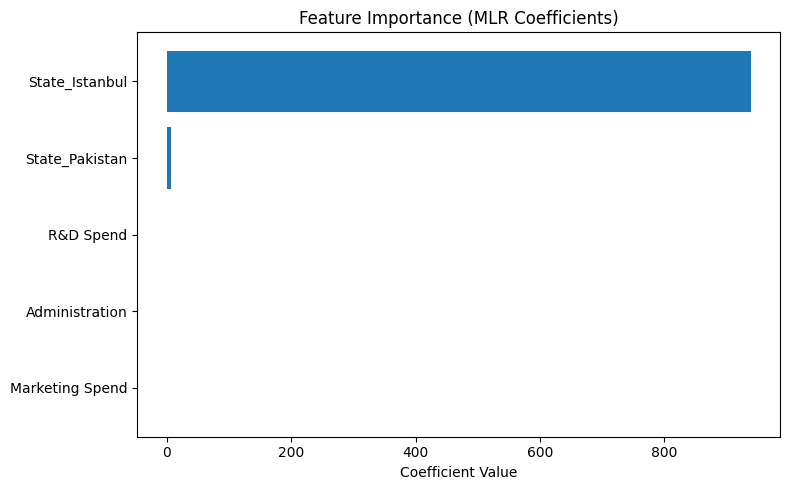

In [24]:
# Step 10: Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Importance (MLR Coefficients)')
plt.tight_layout()
plt.show()

## Step 11: Conclusion & Key Takeaways

Write your findings below. Answer these questions:

1. **What R² score did your model achieve?** Is this good for a regression model?
2. **Which feature has the highest impact on profit?** Why does this make business sense?
3. **Does the State/location significantly affect profit?** What do the coefficients tell you?
4. **What are the limitations of this model?** (Think: dataset size, linearity assumption, outliers)
5. **What would you try next to improve the model?** (Think: polynomial features, regularization, more data)

---

### Your Findings:

**R² Score:** 0.8987

**Most important feature:** R & D SPEND 

**Business insight:** 
--> HighIncrease R&D budget — it directly drives profit 
--> MediumInvest in Marketing — good return on profit
--> LowControl Admin costs — little to no profit impact

**Limitations:** 

1. Correlation doesn't prove causation — other hidden factors may drive profit.
2. Only linear relationships are captured — non-linear patterns are completely missed.
3. Administration's indirect importance (HR, legal) is ignored by the low correlation value.
4. State/regional differences are absent from the heatmap, hiding geographic profit variation.
5. Outliers can heavily skew correlation values, making results unreliable.
6. High R&D–Marketing correlation (0.72) risks multicollinearity in regression models.

**Next steps:** 
1. Add squared/interaction terms to capture non-linear relationships.
2. Use Ridge (L2) to reduce overfitting caused by correlated features.
3. Use Lasso (L1) to automatically eliminate weak features like Administration.
4. Collect more data and include additional features like industry type and company age.
5. Try advanced models like Random Forest or XGBoost for better accuracy.

In [28]:
# (Optional) Step 11: Predict profit for a new startup


import warnings
warnings.filterwarnings('ignore')
new_startup = pd.DataFrame({
    'R&D Spend': [160000],
    'Administration': [130000],
    'Marketing Spend': [300000],
    'State_Istanbul': [1],
    'State_Pakistan': [0]
})
predicted_profit = model.predict(new_startup)
print(f"Predicted Profit for new startup: ${predicted_profit[0]:,.2f}")

Predicted Profit for new startup: $183,881.85


---
**Submission Checklist:**
- [👍] All cells executed without errors
- [👍] EDA section has at least 3 visualizations
- [👍] Model trained with R² score printed
- [👍] Actual vs Predicted plot included
- [👍] Feature importance chart included
- [👍] Conclusion section filled with your own analysis

---
*Corvit / NAVTTC / SAI - AI (ML | DL) Foundation Course*